# Network Topology
1. Deployment Shift (4 examples)
2. Initial Weight Matrix Not Doubly-stochastic 
3. Test accuracy and Convergence Table for Each of 4 topologies

In [1]:
%load_ext autoreload
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
from itertools import product

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF
local_seed = seed('exp10','network-topology')

In [5]:
global_dataset = fetch_dataset('MNIST')

In [6]:
# TEMP
gf_train = GraphFactory(config['train']['num_nodes'], config['train']['b'], local_seed)
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
clf = ByzClassifier(config, global_dataset, gf_train, rng('byz-classifier'))
proj_const_estimator.configure(gf_train, config)
proj_const = proj_const_estimator.estimate()

In [7]:
clf_sim_data = clf.run_simulations(config, proj_const, local_seed + 111, 
                                   beta_C=config['train']['beta_C'], gamma_C=config['train']['gamma_C'])

Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 4137264625)
Building validation set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 2677053567)
  test set (sim 52810965833)
Building test set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 52810965833)


In [21]:
%%capture
fig, ax = plt.subplots(1,2,figsize=(10,4))

In [22]:
C_best_est, C_pre_pipe = clf.train_and_eval(in_model='lin-lr')
C_op_pt = clf.calc_optimal_op_pt()
C_metrics = clf.test()
clf.plot_roc(ax[0])

In [23]:
C_best_est, C_pre_pipe = clf.train_and_eval(in_model='rbf')
C_op_pt = clf.calc_optimal_op_pt()
C_metrics = clf.test()
clf.plot_roc(ax[1])

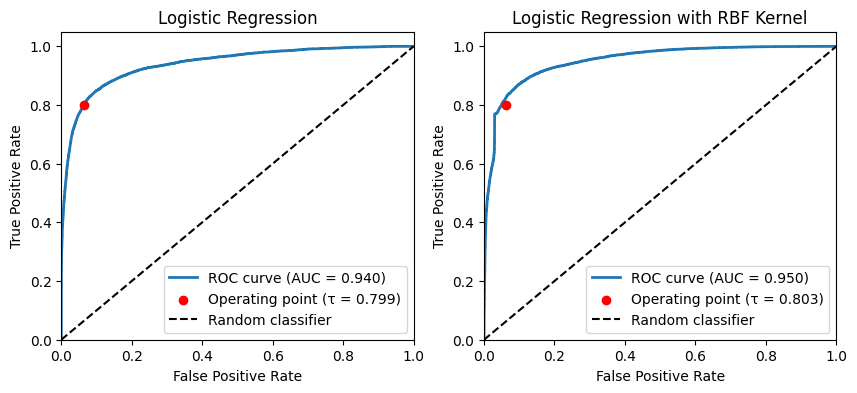

In [25]:
ax[0].set_title("Logistic Regression")
ax[1].set_title("Logistic Regression with RBF Kernel")
display(fig)
fig.savefig('clf_models.png')

In [6]:
# NOT TEMP
graphs = ['erdos-renyi', 'random-regular','watts-strogatz', 'geometric']
graph_args = lambda b : {
    'erdos-renyi': {'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES)},
    'random-regular': {'rand_reg_deg':b+1},
    'watts-strogatz': {'ws_k': 4, 'ws_p': 0.1},
    'geometric': {'geom_radius': 0.34},
}

In [7]:
config = BASE_CONF
config['sys']['atk_type'] = 'label_flip' # chosen because of lowest classifier accuracy (exp8)
config['train']['train_atks'] = [config['sys']['atk_type']] 
config['train']['test_atks'] = config['train']['train_atks'] 

ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD']
sim_params = {'algorithms': ['RDSGD'], 
              'atk_type': config['sys']['atk_type'], 
              'threat_model': 'T3', 
              'seed': local_seed + 333}

**Training Phase**

In [8]:
config['graph_type'] = 'erdos-renyi' # Training Topology
config['graph_args'] = graph_args(config['train']['b'])['erdos-renyi']

# Set number of Byzantines considered in training phase
config['train']['b'] = 4
gf_train = GraphFactory(config['train']['num_nodes'], config['train']['b'], local_seed)
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
clf = ByzClassifier(config, global_dataset, gf_train, rng('byz-classifier'))

prelim_metrics = dict()
proj_const_estimator.configure(gf_train, config)
proj_const = proj_const_estimator.estimate()
prelim_metrics['proj_const'] = proj_const



In [9]:
clf_sim_data = clf.run_simulations(config, proj_const, local_seed + 111, 
                                   beta_C=config['train']['beta_C'], gamma_C=config['train']['gamma_C'])

Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['label_flip'] (seed 4137264625)
Building validation set. Simulating ['label_flip'] (seed 2677053567)
  test set (sim 52810965833)
Building test set. Simulating ['label_flip'] (seed 52810965833)


**Testing Phase**

In [9]:
sys_sim_seed = local_seed + 4444
results = dict()

In [10]:
# Baseline: simulating over same topology 
config['sys']['b'] = config['train']['b']
sys_sim = SystemSimulator(config, global_dataset, rng(sys_sim_seed), LOGFILE)
sys_sim.configure(gf_train, config, proj_const, C_pre_pipe, C_best_est, C_op_pt)
df_base = sys_sim.simulate(sim_params, results)

==========RDSGD==========
[k=50] train_loss: [1.367,1.671],test_acc: [0.850,0.857]
[k=100] train_loss: [1.392,1.671],test_acc: [0.854,0.859]
[k=150] train_loss: [1.423,1.672],test_acc: [0.857,0.860]


In [13]:
# 1. Keep the number of Byzantines and change the topology
config['graph_type'] = 'random-regular' # Test Topology 1
config['graph_args'] = graph_args(config['train']['b'])['random-regular']
config['sys']['b'] = config['train']['b']
gf_test1 = GraphFactory(config['train']['num_nodes'], config['sys']['b'], seed('graph','test','one'))
sys_sim = SystemSimulator(config, global_dataset, rng(sys_sim_seed), LOGFILE)
sys_sim.configure(gf_test1, config, proj_const, C_pre_pipe, C_best_est, C_op_pt) # generate test topology
df_test1 = sys_sim.simulate(sim_params, results)

==========RDSGD==========
[k=50] train_loss: [1.310,1.715],test_acc: [0.832,0.852]
[k=100] train_loss: [1.387,1.745],test_acc: [0.841,0.849]
[k=150] train_loss: [1.390,1.754],test_acc: [0.844,0.849]


In [14]:
# 2. Change both the number of Byzantines and the topology
config['graph_type'] = 'watts-strogatz' 
config['graph_args'] = graph_args(config['train']['b'])['watts-strogatz']

# Changing the number of Byzantines requires re-initialization
config['sys']['b'] = 2
gf_test2 = GraphFactory(config['train']['num_nodes'], config['sys']['b'], seed('graph','test','two'))
sys_sim = SystemSimulator(config, global_dataset, rng(sys_sim_seed), LOGFILE)
sys_sim.configure(gf_test2, config, proj_const, C_pre_pipe, C_best_est, C_op_pt) # generate test topology
df_test2 = sys_sim.simulate(sim_params, results)

==========RDSGD==========
[k=50] train_loss: [1.351,1.635],test_acc: [0.840,0.854]
[k=100] train_loss: [1.367,1.644],test_acc: [0.848,0.854]
[k=150] train_loss: [1.378,1.641],test_acc: [0.850,0.855]


In [17]:
# 3. Change the number of Byzantines, keep the training topology
config['graph_type'] = 'erdos-renyi' 
config['graph_args'] = graph_args(config['train']['b'])['erdos-renyi']

# Changing the number of Byzantines requires re-initialization
config['sys']['b'] = 7
gf_test3 = GraphFactory(config['train']['num_nodes'], config['sys']['b'], seed('graph','test','two'))
sys_sim = SystemSimulator(config, global_dataset, rng(sys_sim_seed), LOGFILE)
sys_sim.configure(gf_test3, config, proj_const, C_pre_pipe, C_best_est, C_op_pt) # generate test topology
df_test3 = sys_sim.simulate(sim_params, results)

==========RDSGD==========
[k=50] train_loss: [1.494,1.878],test_acc: [0.817,0.828]
[k=100] train_loss: [1.518,1.879],test_acc: [0.813,0.821]
[k=150] train_loss: [1.532,1.882],test_acc: [0.813,0.817]
